In [2]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()   # choose spam_dataset.csv

Saving spam_dataset.csv to spam_dataset.csv


In [4]:
df = pd.read_csv('spam_dataset.csv')
df.head()

,text,label
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham


In [5]:
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'<.*?>', ' ', t)
    t = re.sub(r'http\S+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

df['clean'] = df['text'].apply(clean_text)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(df['clean'], df['label'], test_size=0.2, random_state=1, stratify=df['label'])

SVM Accuracy: 0.9865470852017937
SVM Precision: 0.9855072463768116
SVM Recall: 0.912751677852349
SVM F1: 0.9477351916376306


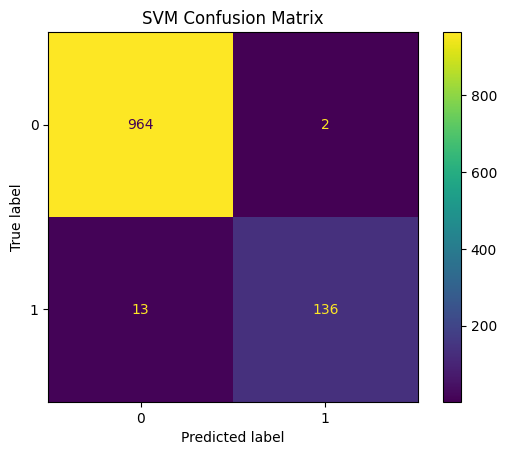

In [7]:
vec_svm = TfidfVectorizer(max_features=3000)
X_train_v = vec_svm.fit_transform(X_train)
X_test_v = vec_svm.transform(X_test)

svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train_v, y_train)
pred_svm = svm_model.predict(X_test_v)

print("SVM Accuracy:", accuracy_score(y_test, pred_svm))
print("SVM Precision:", precision_score(y_test, pred_svm, pos_label='spam'))
print("SVM Recall:", recall_score(y_test, pred_svm, pos_label='spam'))
print("SVM F1:", f1_score(y_test, pred_svm, pos_label='spam'))

cm = confusion_matrix(y_test, pred_svm)
ConfusionMatrixDisplay(cm).plot()
plt.title("SVM Confusion Matrix")
plt.show()

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense

tok = Tokenizer(num_words=3000)
tok.fit_on_texts(X_train)
X_train_seq = pad_sequences(tok.texts_to_sequences(X_train), maxlen=80)
X_test_seq = pad_sequences(tok.texts_to_sequences(X_test), maxlen=80)
y_train_n = (y_train == 'spam').astype(int)
y_test_n = (y_test == 'spam').astype(int)

cnn_model = Sequential([
    Embedding(3000, 32, input_length=80),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_seq, y_train_n, epochs=3, batch_size=32, validation_split=0.1)

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8574 - loss: 0.3999 - val_accuracy: 0.8879 - val_loss: 0.2567
Epoch 2/3
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9479 - loss: 0.1467 - val_accuracy: 0.9753 - val_loss: 0.0816
Epoch 3/3
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9823 - loss: 0.0607 - val_accuracy: 0.9776 - val_loss: 0.0572


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
CNN Accuracy: 0.9829596412556054
CNN Precision: 0.9779411764705882
CNN Recall: 0.8926174496644296
CNN F1: 0.9333333333333333


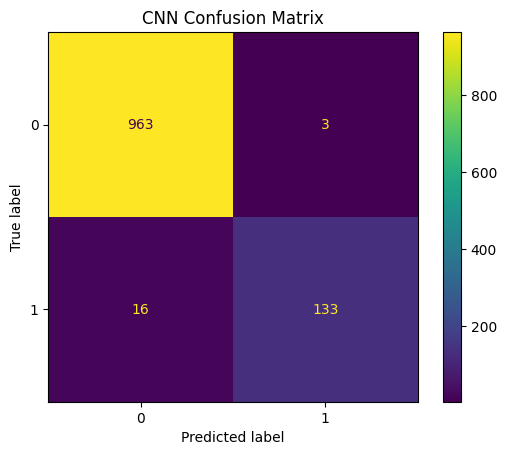

In [9]:
pred_cnn_prob = cnn_model.predict(X_test_seq)
pred_cnn = (pred_cnn_prob > 0.5).astype(int).flatten()

print("CNN Accuracy:", accuracy_score(y_test_n, pred_cnn))
print("CNN Precision:", precision_score(y_test_n, pred_cnn))
print("CNN Recall:", recall_score(y_test_n, pred_cnn))
print("CNN F1:", f1_score(y_test_n, pred_cnn))

cm2 = confusion_matrix(y_test_n, pred_cnn)
ConfusionMatrixDisplay(cm2).plot()
plt.title("CNN Confusion Matrix")
plt.show()